# CSC4093 / DSC4213: Deep Learning — Programming Assignment 02
## Tea Leaf Disease Classification using Transfer Learning
### Models: VGG16 and ResNet50
**Classes:** Algal Leaf | Brown Blight | White Spot

## 1. Setup & Imports

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.models import VGG16_Weights, ResNet50_Weights

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Configuration

In [4]:
# ── Edit this path to point at your Data_A2 folder ──────────────────────────
DATA_DIR   = './Data_A2'       # folder containing 'algal leaf', 'brown blight', 'white spot'
# ─────────────────────────────────────────────────────────────────────────────

IMG_SIZE   = 224               # VGG16 & ResNet50 both expect 224×224
BATCH_SIZE = 16
NUM_EPOCHS = 15
LR         = 1e-4              # learning rate
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
NUM_CLASSES = 3
CLASS_NAMES = ['algal leaf', 'brown blight', 'white spot']

## 3. Data Loading & Augmentation

In [5]:
# ImageNet normalisation statistics (required for pre-trained weights)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load full dataset (train transform applied during training via custom split)
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
full_dataset_eval = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)

total = len(full_dataset)
n_train = int(TRAIN_SPLIT * total)
n_val   = int(VAL_SPLIT   * total)
n_test  = total - n_train - n_val

# Reproducible split
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(total, generator=generator).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

from torch.utils.data import Subset
train_set = Subset(full_dataset,      train_idx)
val_set   = Subset(full_dataset_eval, val_idx)
test_set  = Subset(full_dataset_eval, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Total images : {total}')
print(f'Train        : {len(train_set)}')
print(f'Validation   : {len(val_set)}')
print(f'Test         : {len(test_set)}')
print(f'Classes      : {full_dataset.classes}')

Total images : 368
Train        : 257
Validation   : 55
Test         : 56
Classes      : ['algal leaf', 'brown blight', 'white spot']


### 3.1 Visualise Sample Images

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


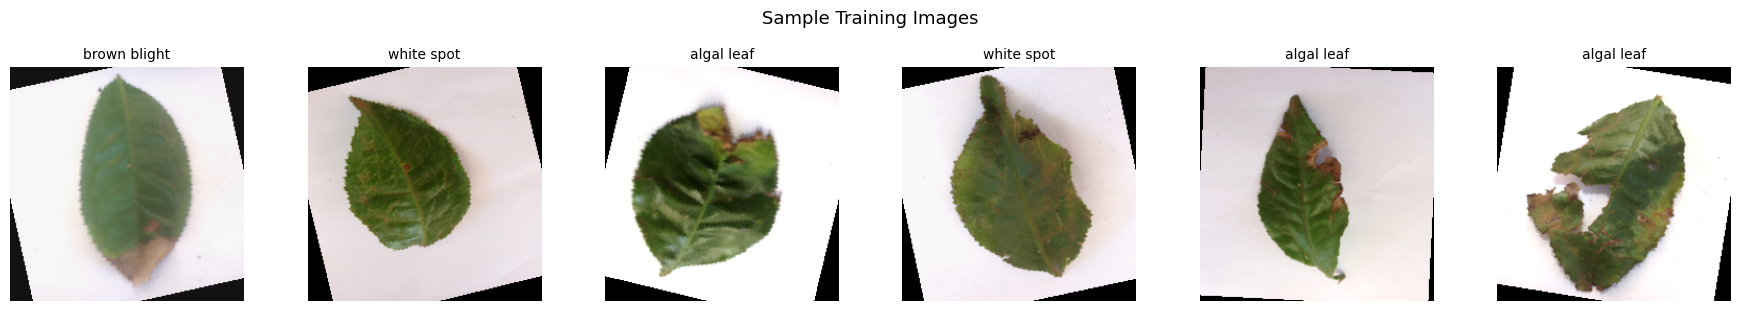

In [6]:
def imshow_grid(loader, classes, n=6):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n]
    
    # Un-normalise for display
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = imgs * std + mean
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for ax, img, lbl in zip(axes, imgs, labels):
        ax.imshow(img.permute(1,2,0).numpy())
        ax.set_title(classes[lbl], fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Training Images', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

imshow_grid(train_loader, full_dataset.classes)

## 4. Model Builder

In [7]:
def build_vgg16(num_classes: int, freeze_features: bool = True) -> nn.Module:
    """VGG-16 with pre-trained ImageNet weights. Replace classifier head."""
    model = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace the 4096→1000 final layer with 4096→num_classes
    in_features = model.classifier[6].in_features     # 4096
    model.classifier[6] = nn.Linear(in_features, num_classes)

    return model


def build_resnet50(num_classes: int, freeze_features: bool = True) -> nn.Module:
    """ResNet-50 with pre-trained ImageNet weights. Replace FC head."""
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False

    # Replace 2048→1000 head with 2048→num_classes
    in_features = model.fc.in_features                # 2048
    model.fc = nn.Linear(in_features, num_classes)

    return model


# Quick sanity-check: count trainable parameters
def count_params(model):
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Total params    : {total:,}')
    print(f'  Trainable params: {trainable:,}')

print('VGG-16')
vgg = build_vgg16(NUM_CLASSES)
count_params(vgg)

print('\nResNet-50')
res = build_resnet50(NUM_CLASSES)
count_params(res)

VGG-16
  Total params    : 134,272,835
  Trainable params: 119,558,147

ResNet-50
  Total params    : 23,514,179
  Trainable params: 6,147


## 5. Training & Evaluation Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs, device, model_name='model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'[{model_name}] Epoch {epoch:02d}/{num_epochs} | '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}')

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f'\nBest validation accuracy: {best_val_acc:.4f}')
    return model, history

## 6. Train VGG-16

In [9]:
vgg_model = build_vgg16(NUM_CLASSES, freeze_features=True).to(DEVICE)

criterion   = nn.CrossEntropyLoss()
vgg_opt     = optim.Adam(filter(lambda p: p.requires_grad, vgg_model.parameters()), lr=LR)
vgg_sched   = optim.lr_scheduler.ReduceLROnPlateau(vgg_opt, mode='min', factor=0.5, patience=3)

vgg_model, vgg_history = train_model(
    vgg_model, train_loader, val_loader,
    criterion, vgg_opt, vgg_sched,
    NUM_EPOCHS, DEVICE, model_name='VGG-16'
)

# Save weights
torch.save(vgg_model.state_dict(), 'vgg16_tea_leaf.pth')
print('VGG-16 weights saved.')

[VGG-16] Epoch 01/15 | Train Loss: 1.0711  Acc: 0.4202 | Val Loss: 0.9166  Acc: 0.6182
[VGG-16] Epoch 02/15 | Train Loss: 0.9394  Acc: 0.5525 | Val Loss: 0.8311  Acc: 0.6182
[VGG-16] Epoch 03/15 | Train Loss: 0.8130  Acc: 0.6420 | Val Loss: 0.8647  Acc: 0.6364
[VGG-16] Epoch 04/15 | Train Loss: 0.8318  Acc: 0.6498 | Val Loss: 0.6682  Acc: 0.7636
[VGG-16] Epoch 05/15 | Train Loss: 0.7588  Acc: 0.6459 | Val Loss: 0.6606  Acc: 0.7455
[VGG-16] Epoch 06/15 | Train Loss: 0.8231  Acc: 0.6459 | Val Loss: 0.6727  Acc: 0.6909
[VGG-16] Epoch 07/15 | Train Loss: 0.7385  Acc: 0.6770 | Val Loss: 0.5952  Acc: 0.7636
[VGG-16] Epoch 08/15 | Train Loss: 0.6416  Acc: 0.7549 | Val Loss: 0.6040  Acc: 0.7273
[VGG-16] Epoch 09/15 | Train Loss: 0.4762  Acc: 0.8093 | Val Loss: 0.5698  Acc: 0.7636
[VGG-16] Epoch 10/15 | Train Loss: 0.6472  Acc: 0.7315 | Val Loss: 0.5994  Acc: 0.8364
[VGG-16] Epoch 11/15 | Train Loss: 0.6507  Acc: 0.7276 | Val Loss: 0.5832  Acc: 0.8182
[VGG-16] Epoch 12/15 | Train Loss: 0.4804  

## 7. Train ResNet-50

In [10]:
res_model = build_resnet50(NUM_CLASSES, freeze_features=True).to(DEVICE)

res_opt   = optim.Adam(filter(lambda p: p.requires_grad, res_model.parameters()), lr=LR)
res_sched = optim.lr_scheduler.ReduceLROnPlateau(res_opt, mode='min', factor=0.5, patience=3)

res_model, res_history = train_model(
    res_model, train_loader, val_loader,
    criterion, res_opt, res_sched,
    NUM_EPOCHS, DEVICE, model_name='ResNet-50'
)

torch.save(res_model.state_dict(), 'resnet50_tea_leaf.pth')
print('ResNet-50 weights saved.')

[ResNet-50] Epoch 01/15 | Train Loss: 1.1083  Acc: 0.3385 | Val Loss: 1.0805  Acc: 0.3818
[ResNet-50] Epoch 02/15 | Train Loss: 1.0693  Acc: 0.4086 | Val Loss: 1.0609  Acc: 0.5091
[ResNet-50] Epoch 03/15 | Train Loss: 1.0527  Acc: 0.4669 | Val Loss: 1.0560  Acc: 0.4000
[ResNet-50] Epoch 04/15 | Train Loss: 1.0375  Acc: 0.4903 | Val Loss: 1.0293  Acc: 0.4727
[ResNet-50] Epoch 05/15 | Train Loss: 1.0322  Acc: 0.5409 | Val Loss: 1.0395  Acc: 0.4364
[ResNet-50] Epoch 06/15 | Train Loss: 1.0450  Acc: 0.4319 | Val Loss: 1.0045  Acc: 0.6182
[ResNet-50] Epoch 07/15 | Train Loss: 1.0178  Acc: 0.5253 | Val Loss: 1.0417  Acc: 0.4909
[ResNet-50] Epoch 08/15 | Train Loss: 1.0115  Acc: 0.5564 | Val Loss: 0.9936  Acc: 0.4727
[ResNet-50] Epoch 09/15 | Train Loss: 0.9971  Acc: 0.5837 | Val Loss: 0.9798  Acc: 0.6364
[ResNet-50] Epoch 10/15 | Train Loss: 0.9693  Acc: 0.6070 | Val Loss: 0.9688  Acc: 0.6545
[ResNet-50] Epoch 11/15 | Train Loss: 0.9768  Acc: 0.5759 | Val Loss: 0.9852  Acc: 0.4727
[ResNet-50

## 8. Test Set Evaluation

In [12]:
vgg_test_loss, vgg_test_acc, vgg_preds, vgg_labels = evaluate(vgg_model, test_loader, criterion, DEVICE)
res_test_loss, res_test_acc, res_preds, res_labels = evaluate(res_model, test_loader, criterion, DEVICE)

print('=' * 60)
print(f'VGG-16   — Test Loss: {vgg_test_loss:.4f}  |  Test Accuracy: {vgg_test_acc*100:.2f}%')
print(f'ResNet-50 — Test Loss: {res_test_loss:.4f}  |  Test Accuracy: {res_test_acc*100:.2f}%')
print('=' * 60)

VGG-16   — Test Loss: 0.7411  |  Test Accuracy: 69.64%
ResNet-50 — Test Loss: 0.9903  |  Test Accuracy: 58.93%


## 9. Classification Reports

In [13]:
print('──── VGG-16 Classification Report ────')
print(classification_report(vgg_labels, vgg_preds, target_names=CLASS_NAMES))

print('──── ResNet-50 Classification Report ────')
print(classification_report(res_labels, res_preds, target_names=CLASS_NAMES))

──── VGG-16 Classification Report ────
              precision    recall  f1-score   support

  algal leaf       0.77      0.67      0.71        15
brown blight       1.00      0.25      0.40        16
  white spot       0.64      1.00      0.78        25

    accuracy                           0.70        56
   macro avg       0.80      0.64      0.63        56
weighted avg       0.78      0.70      0.65        56

──── ResNet-50 Classification Report ────
              precision    recall  f1-score   support

  algal leaf       0.59      0.87      0.70        15
brown blight       0.50      0.44      0.47        16
  white spot       0.65      0.52      0.58        25

    accuracy                           0.59        56
   macro avg       0.58      0.61      0.58        56
weighted avg       0.59      0.59      0.58        56



## 10. Visualisations

### 10.1 Training Curves — Loss & Accuracy

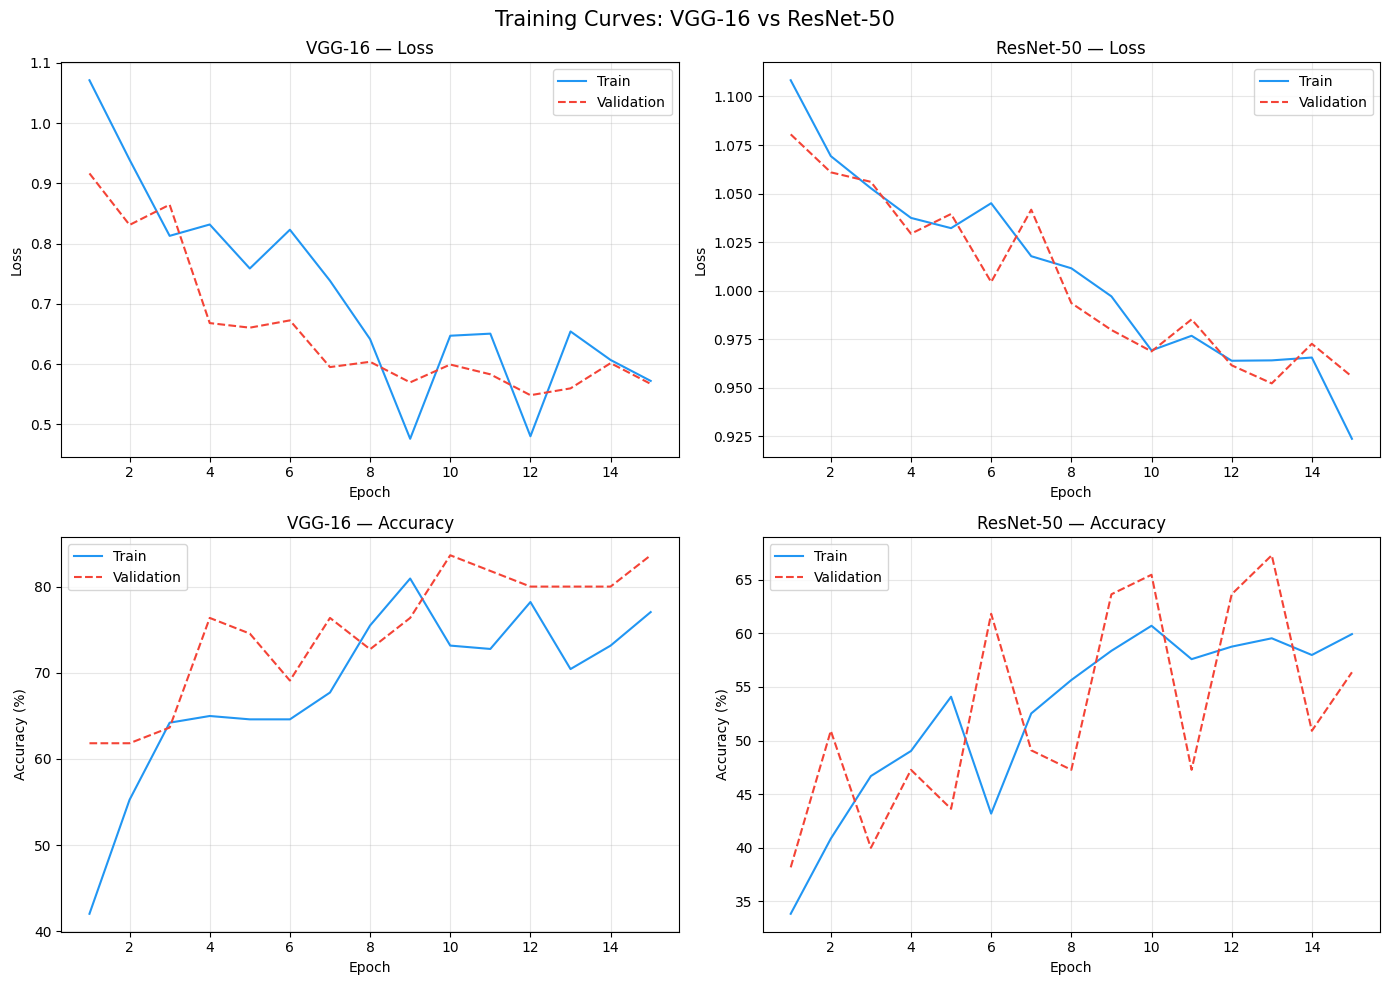

Saved: training_curves.png


In [14]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves: VGG-16 vs ResNet-50', fontsize=15)

colors = {'train': '#2196F3', 'val': '#F44336'}

for col, (name, hist) in enumerate(zip(['VGG-16', 'ResNet-50'], [vgg_history, res_history])):
    ax_loss = axes[0][col]
    ax_acc  = axes[1][col]

    ax_loss.plot(epochs, hist['train_loss'], color=colors['train'], label='Train')
    ax_loss.plot(epochs, hist['val_loss'],   color=colors['val'],   label='Validation', linestyle='--')
    ax_loss.set_title(f'{name} — Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, [a*100 for a in hist['train_acc']], color=colors['train'], label='Train')
    ax_acc.plot(epochs, [a*100 for a in hist['val_acc']],   color=colors['val'],   label='Validation', linestyle='--')
    ax_acc.set_title(f'{name} — Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

### 10.2 Confusion Matrices

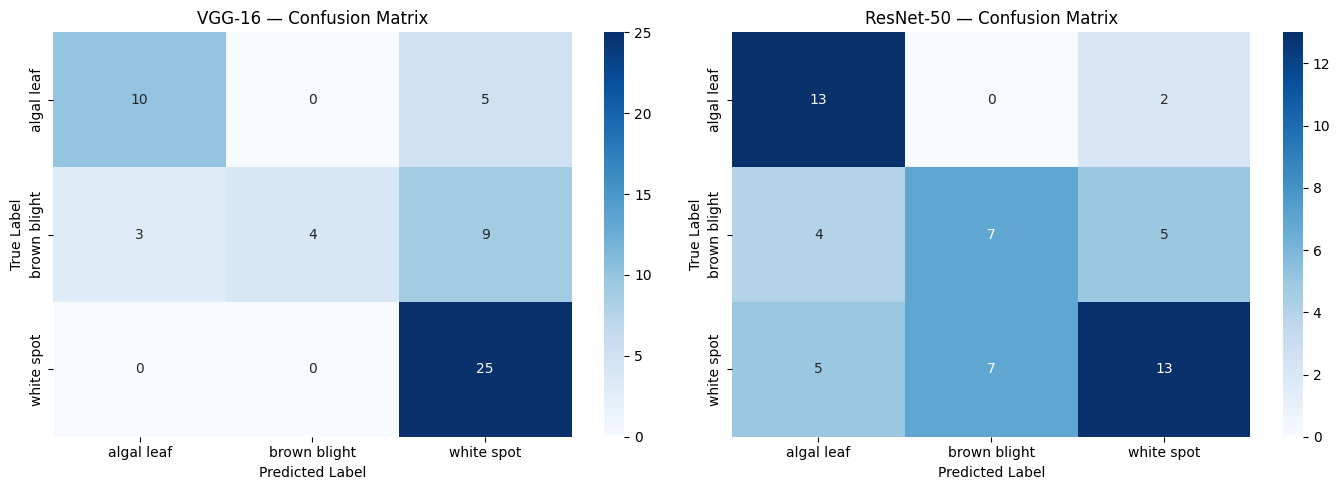

Saved: confusion_matrices.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, labels, name in zip(
    axes,
    [vgg_preds,    res_preds],
    [vgg_labels,   res_labels],
    ['VGG-16',     'ResNet-50']):

    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### 10.3 Side-by-Side Model Comparison Bar Chart

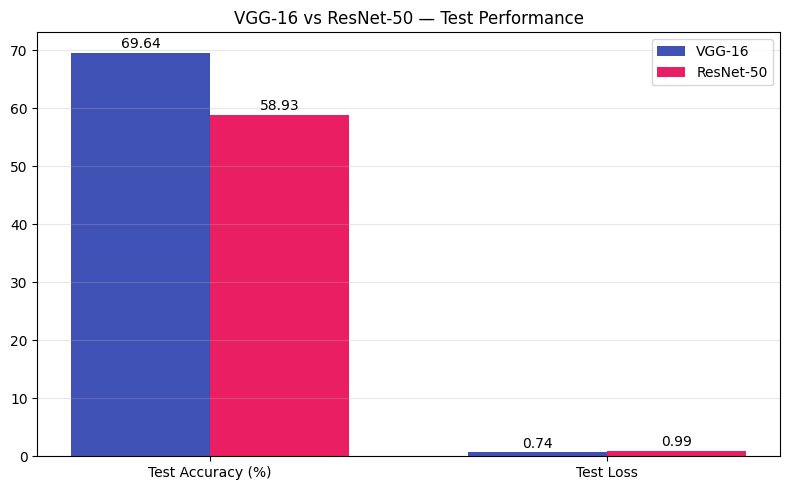

Saved: model_comparison.png


In [16]:
metrics_labels = ['Test Accuracy (%)', 'Test Loss']
vgg_vals = [vgg_test_acc * 100, vgg_test_loss]
res_vals = [res_test_acc * 100, res_test_loss]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, vgg_vals, width, label='VGG-16',    color='#3F51B5')
bars2 = ax.bar(x + width/2, res_vals, width, label='ResNet-50', color='#E91E63')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_title('VGG-16 vs ResNet-50 — Test Performance')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

### 10.4 Per-Class F1-Score Comparison

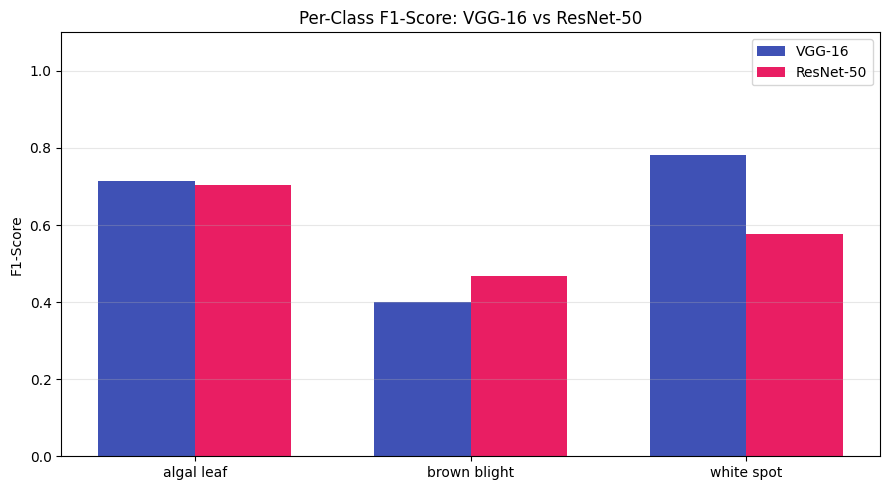

Saved: f1_comparison.png


In [17]:
from sklearn.metrics import f1_score

vgg_f1 = f1_score(vgg_labels, vgg_preds, average=None)
res_f1 = f1_score(res_labels, res_preds, average=None)

x = np.arange(NUM_CLASSES)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, vgg_f1, width, label='VGG-16',    color='#3F51B5')
ax.bar(x + width/2, res_f1, width, label='ResNet-50', color='#E91E63')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score: VGG-16 vs ResNet-50')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: f1_comparison.png')

## 11. Summary Table

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def model_summary(name, preds, labels, loss):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted')
    rec  = recall_score(labels, preds, average='weighted')
    f1   = f1_score(labels, preds, average='weighted')
    print(f'{name:<12} | Acc: {acc*100:5.2f}% | Loss: {loss:.4f} | '
          f'Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

print('Model        | Accuracy | Test Loss | Precision | Recall  | F1-Score')
print('-' * 75)
model_summary('VGG-16',    vgg_preds, vgg_labels, vgg_test_loss)
model_summary('ResNet-50', res_preds, res_labels, res_test_loss)

Model        | Accuracy | Test Loss | Precision | Recall  | F1-Score
---------------------------------------------------------------------------
VGG-16       | Acc: 69.64% | Loss: 0.7411 | Precision: 0.7779 | Recall: 0.6964 | F1: 0.6544
ResNet-50    | Acc: 58.93% | Loss: 0.9903 | Precision: 0.5913 | Recall: 0.5893 | F1: 0.5795


## 12. Predict on a Single Image

Running inference on: Data_A2/white spot/UNADJUSTEDNONRAW_thumb_e3.jpg


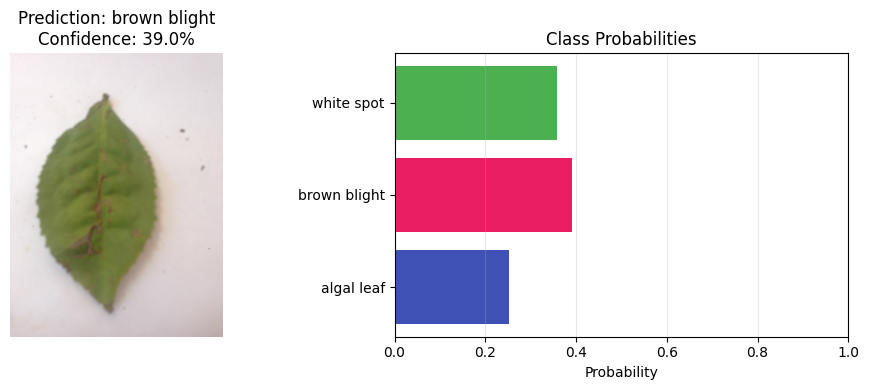

Predicted: brown blight  |  Probabilities: {'algal leaf': np.float32(0.2518), 'brown blight': np.float32(0.3904), 'white spot': np.float32(0.3578)}


In [19]:
from PIL import Image

def predict_single(model, image_path, transform, class_names, device):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    pred_idx = probs.argmax().item()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Prediction: {class_names[pred_idx]}\nConfidence: {probs[pred_idx]*100:.1f}%')
    axes[0].axis('off')

    axes[1].barh(class_names, probs.cpu().numpy(), color=['#3F51B5','#E91E63','#4CAF50'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Class Probabilities')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return class_names[pred_idx], probs.cpu().numpy()

# ── Example: change this path to any image you want to test ─────────────────
sample_img = next(iter(Path(DATA_DIR).rglob('*.jpg')))
print(f'Running inference on: {sample_img}')
label, probs = predict_single(res_model, str(sample_img), val_test_transform, CLASS_NAMES, DEVICE)
print(f'Predicted: {label}  |  Probabilities: {dict(zip(CLASS_NAMES, probs.round(4)))}')